# Actividad 2 - Clase 4: Regresión Logística

En esta actividad se aplica un modelo de regresión logística para clasificar el sistema operativo utilizado por usuarios que visitan un sitio web.

El dataset utilizado es `usuarios_win_mac_lin.csv`, propuesto en la Clase 4. La variable objetivo es `clase`, que representa el sistema operativo del usuario:

- 0: Windows
- 1: Macintosh
- 2: Linux

Las variables predictoras son `duracion`, `paginas`, `acciones` y `valor`, que describen el comportamiento del usuario dentro del sitio web.

Como la variable objetivo es categórica, este problema corresponde a una tarea de clasificación dentro del aprendizaje supervisado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [8]:
# CARGAR DATASET
df = pd.read_csv("/usuarios_win_mac_lin.csv", encoding="ISO-8859-1")

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [9]:
# INFORMACIÓN Y ESTADISTICA DEL DATASET
print(df.info())

print(df.describe())

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB
None
         duracion     paginas    acciones       valor       clase
count  170.000000  170.000000  170.000000  170.000000  170.000000
mean   111.075729    2.041176    8.723529   32.676471    0.752941
std    202.453200    1.500911    9.136054   44.751993    0.841327
min      1.000000    1.000000    1.000000    1.000000    0.000000
25%     11.000000    1.000000    3.000000    8.000000    0.000000
50%     13.000000    2.000000    6.000000   20.000000    0.000000
75%    108.000000    2.000000   10.000000   36.000000    2.000000
max    898.000000    9.000000   63.00000

,0
duracion,0
paginas,0
acciones,0
valor,0
clase,0


El dataset contiene información relacionada con el comportamiento de usuarios dentro de un sitio web.

Las variables predictoras utilizadas son:
- duración
- páginas
- acciones
- valor

La variable objetivo es `clase`, la cual representa el sistema operativo utilizado por el usuario:
- 0 → Windows
- 1 → Macintosh
- 2 → Linux

Debido a que la variable objetivo corresponde a categorías, este problema pertenece a una tarea de clasificación dentro del aprendizaje supervisado.

In [10]:
# DEFINIMOS "X" Y "Y"
X = df.drop("clase", axis=1)

y = df["clase"]

In [11]:
# TRAIN_TEST_SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# MODELO REGRESIÓN LOGISTICA
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
#PREDICCIONES
y_pred = modelo.predict(X_test)

In [14]:
# METRICAS
print("Precisión Global (Accuracy):",
      accuracy_score(y_test, y_pred))

print("\nReporte de Clasificación:\n")

print(classification_report(y_test, y_pred))

Precisión Global (Accuracy): 0.6764705882352942

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



Las métricas obtenidas permiten evaluar el rendimiento del modelo de regresión logística utilizado para clasificar el sistema operativo de los usuarios.

La precisión global (Accuracy) obtenida fue aproximadamente de 0.68, lo que indica que el modelo logró clasificar correctamente cerca del 68% de los casos evaluados.

El reporte de clasificación permite analizar el desempeño individual de cada clase:

- La clase 0 (Windows) obtuvo un buen nivel de recall, indicando que la mayoría de los usuarios Windows fueron correctamente identificados.
- La clase 1 (Macintosh) presentó un desempeño más bajo en comparación con las demás clases, mostrando mayores dificultades para clasificar correctamente algunos registros.
- La clase 2 (Linux) obtuvo los mejores resultados, con métricas elevadas de precisión y recall.

En general, el modelo logró aprender patrones presentes en los datos y realizar predicciones aceptables sobre el sistema operativo utilizado por los usuarios del sitio web.

<Figure size 800x600 with 0 Axes>

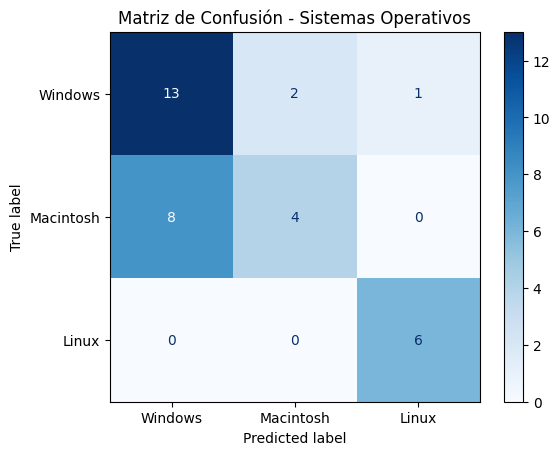

In [15]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Windows", "Macintosh", "Linux"]
).plot(cmap="Blues")

plt.title("Matriz de Confusión - Sistemas Operativos")

plt.show()

La matriz de confusión permite observar cómo el modelo clasificó los distintos sistemas operativos.

Los valores ubicados en la diagonal principal representan las clasificaciones correctas realizadas por el modelo. Por ejemplo:

- El modelo logró clasificar correctamente 13 usuarios Windows.
- También identificó correctamente 6 usuarios Linux.
- En algunos casos existieron errores de clasificación, especialmente entre usuarios Windows y Macintosh.

Esto indica que ciertos patrones entre ambas clases pueden ser similares para el algoritmo, dificultando su diferenciación.

En general, el modelo presentó un desempeño aceptable y logró identificar correctamente la mayoría de los sistemas operativos presentes en el conjunto de prueba.

# Conclusión

En esta actividad se aplicó un modelo de Regresión Logística utilizando técnicas de aprendizaje supervisado para clasificar sistemas operativos según características de navegación de usuarios.

Se realizó la preparación de datos, división entre entrenamiento y prueba, entrenamiento del modelo y evaluación mediante métricas y matriz de confusión.

Los resultados obtenidos permitieron comprobar que el modelo puede aprender patrones presentes en los datos y realizar predicciones con un nivel de precisión aceptable.

Además, las visualizaciones y métricas facilitaron la interpretación del desempeño del algoritmo, permitiendo analizar tanto los aciertos como los errores de clasificación.

Esta actividad permitió comprender el funcionamiento básico de la regresión logística y su aplicación en problemas de clasificación dentro del aprendizaje automático.